In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

In [22]:
df=pd.read_csv("Iris.csv")
df.drop(columns="Id",inplace=True)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [23]:
le=LabelEncoder()
scale=MinMaxScaler()
X=scale.fit_transform(df[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]])
y=le.fit_transform(df["Species"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
model = Sequential()
model.add(Dense(16, activation="relu", input_shape=(X.shape[1],)))
model.add(Dense(8, activation="relu"))
model.add(Dense(3, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history=model.fit(X_train,y_train,epochs=100,batch_size=4,verbose=0,validation_data=(X_test, y_test))



In [27]:
loss,accuracy=model.evaluate(X_test, y_test)

sample = [[5.1, 3.5, 1.4, 0.2]]

sample = scale.transform(sample)

prediction = model.predict(sample)

class_index = prediction.argmax()

print("\nPredicted Flower:", df.Species[class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9667 - loss: 0.0920
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

Predicted Flower: Iris-setosa


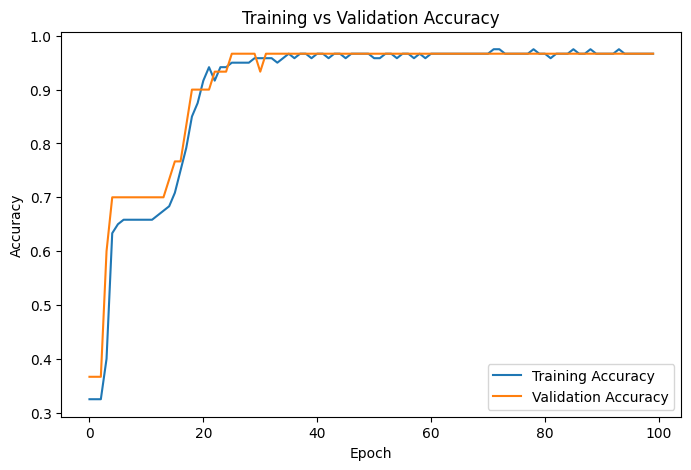

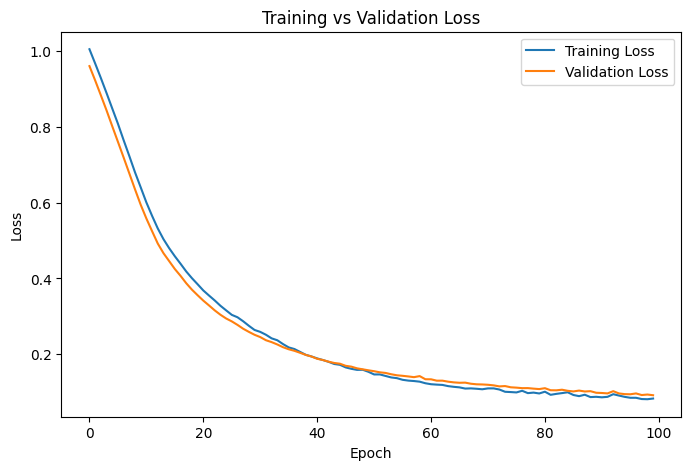

In [30]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

# -----------------------------
# Plot Loss
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()